In [ ]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

# ======================================================
# CONFIGURATION
# ======================================================
BASE_DIR = Path("ML-Features_V1")
REPORT_FILE = Path("ML_Feature_QC_Report.csv")




In [3]:

# ======================================================
# MAIN INSPECTION LOGIC
# ======================================================
def inspect_feature_csvs(base_dir):
    """
    Inspect all CSV files inside the channel subfolders under ML-Features_v1/
    and generate a data-quality summary.
    """
    summary_rows = []

    if not base_dir.exists():
        raise FileNotFoundError(f"❌ Folder not found: {base_dir}")

    channel_folders = sorted([d for d in base_dir.iterdir() if d.is_dir()])
    if not channel_folders:
        raise FileNotFoundError("❌ No channel subfolders found inside ML-Features_v1")

    print(f"🔍 Found {len(channel_folders)} channel folders in {base_dir}")

    for channel_dir in channel_folders:
        channel_name = channel_dir.name
        csv_files = sorted(channel_dir.glob("*.csv"))
        print(f"\n📁 Checking channel: {channel_name} ({len(csv_files)} files)")

        for csv_path in csv_files:
            file_name = csv_path.name
            file_size_kb = round(csv_path.stat().st_size / 1024, 2)

            try:
                df = pd.read_csv(csv_path)

                # Basic info
                n_rows, n_cols = df.shape
                has_nan = df.isna().any().any()
                nan_count_total = df.isna().sum().sum()

                # Duplicates
                duplicate_rows = df.duplicated().sum()

                # Duplicate values per column (how many duplicates, ignoring NaN)
                dup_counts_per_col = {
                    col: df[col].duplicated().sum() for col in df.columns
                }

                # Summarize duplicate percentage
                dup_percent_cols = np.mean([
                    (count / len(df)) * 100 if len(df) > 0 else 0
                    for count in dup_counts_per_col.values()
                ])

                summary_rows.append({
                    "channel": channel_name,
                    "file_name": file_name,
                    "file_size_kb": file_size_kb,
                    "rows": n_rows,
                    "cols": n_cols,
                    "has_nan": has_nan,
                    "total_nan_values": nan_count_total,
                    "duplicate_rows": duplicate_rows,
                    "avg_duplicate_percent_per_col": round(dup_percent_cols, 2)
                })

                # Optional: print warning if anything suspicious
                if has_nan or duplicate_rows > 0:
                    print(f"⚠️  {file_name}: NaNs={nan_count_total}, DuplicateRows={duplicate_rows}")

            except Exception as e:
                print(f"❌ Error reading {csv_path}: {e}")
                summary_rows.append({
                    "channel": channel_name,
                    "file_name": file_name,
                    "file_size_kb": file_size_kb,
                    "rows": None,
                    "cols": None,
                    "has_nan": None,
                    "total_nan_values": None,
                    "duplicate_rows": None,
                    "avg_duplicate_percent_per_col": None
                })

    # Create DataFrame summary
    report_df = pd.DataFrame(summary_rows)
    report_df = report_df.sort_values(by=["channel", "file_name"]).reset_index(drop=True)
    return report_df



In [4]:
# ======================================================
# RUN & SAVE REPORT
# ======================================================
print("🚀 Running EEG Feature Quality Check...\n")

report_df = inspect_feature_csvs(BASE_DIR)


🚀 Running EEG Feature Quality Check...

🔍 Found 24 channel folders in ML-Features_v1

📁 Checking channel: AFz (34 files)

📁 Checking channel: C3 (34 files)

📁 Checking channel: C4 (34 files)

📁 Checking channel: CPz (34 files)

📁 Checking channel: Cz (34 files)

📁 Checking channel: F3 (34 files)

📁 Checking channel: F4 (34 files)

📁 Checking channel: F7 (34 files)

📁 Checking channel: F8 (34 files)

📁 Checking channel: FP1 (34 files)

📁 Checking channel: FP2 (34 files)

📁 Checking channel: Fz (34 files)

📁 Checking channel: M1 (34 files)

📁 Checking channel: M2 (34 files)

📁 Checking channel: O1 (34 files)

📁 Checking channel: O2 (34 files)

📁 Checking channel: P3 (34 files)

📁 Checking channel: P4 (34 files)

📁 Checking channel: P7 (34 files)

📁 Checking channel: P8 (34 files)

📁 Checking channel: POz (34 files)

📁 Checking channel: Pz (34 files)

📁 Checking channel: T7 (34 files)

📁 Checking channel: T8 (34 files)


In [5]:

# Save report
report_df.to_csv(REPORT_FILE, index=False)
print(f"\n✅ Quality check complete! Report saved as → {REPORT_FILE}")

# Display first few lines
print("\n📊 Report preview:")
print(report_df.head(10))


✅ Quality check complete! Report saved as → ML_Feature_QC_Report.csv

📊 Report preview:
  channel         file_name  file_size_kb  rows  cols  has_nan  \
0     AFz   ID0_feature.csv        258.39   237    58    False   
1     AFz  ID10_feature.csv        263.34   239    58    False   
2     AFz  ID11_feature.csv        261.38   239    58    False   
3     AFz  ID13_feature.csv        261.29   239    58    False   
4     AFz  ID14_feature.csv        260.58   239    58    False   
5     AFz  ID15_feature.csv        261.57   239    58    False   
6     AFz  ID16_feature.csv        259.38   239    58    False   
7     AFz  ID18_feature.csv        260.49   239    58    False   
8     AFz  ID19_feature.csv        261.35   239    58    False   
9     AFz   ID1_feature.csv        258.05   239    58    False   

   total_nan_values  duplicate_rows  avg_duplicate_percent_per_col  
0                 0               0                          11.26  
1                 0               0           

In [8]:
sample_df = pd.read_csv("ML-Features_V1\AFz\ID0_feature.csv")

In [10]:
print(sample_df.shape)

print(sample_df.columns)

(237, 58)
Index(['subj_id', 'window_idx', 'label', 'pain_score', 'mean_AFz', 'std_AFz',
       'var_AFz', 'min_AFz', 'max_AFz', 'median_AFz', 'skew_AFz',
       'kurtosis_AFz', 'energy_AFz', 'rms_AFz', 'trim_mean_10_AFz',
       'trim_mean_15_AFz', 'mad_AFz', 'p10_AFz', 'p25_AFz', 'p75_AFz',
       'iqr_AFz', 'cv_AFz', 'mean_diff_AFz', 'std_diff_AFz',
       'mean_abs_diff_AFz', 'max_abs_diff_AFz', 'zero_cross_AFz',
       'signal_energy_AFz', 'sign_change_rate_AFz', 'autocorr_lag1_AFz',
       'tk_energy_AFz', 'delta_AFz', 'theta_AFz', 'alpha_AFz', 'beta_AFz',
       'gamma_AFz', 'rel_delta_AFz', 'rel_theta_AFz', 'rel_alpha_AFz',
       'rel_beta_AFz', 'rel_gamma_AFz', 'theta_alpha_ratio_AFz',
       'theta_beta_ratio_AFz', 'alpha_beta_ratio_AFz', 'hjorth_activity_AFz',
       'hjorth_mobility_AFz', 'hjorth_complexity_AFz', 'spectral_centroid_AFz',
       'spectral_entropy_AFz', 'spectral_edge_90_AFz', 'wavelet_energy_L0_AFz',
       'wavelet_energy_L1_AFz', 'wavelet_energy_L2_AFz',
 

### **Visulization of Feature DATA**

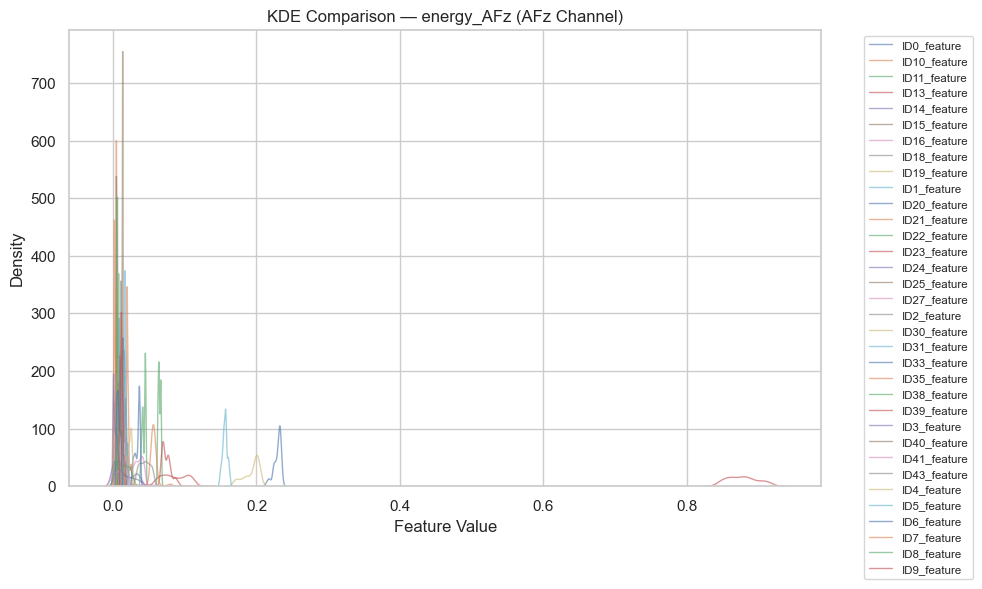

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ======================================================
# CONFIGURATION
# ======================================================
BASE_DIR = Path("ML-Features_v1")   # Base folder containing all channels
CHANNEL_NAME = "AFz"                # e.g., pick one channel folder
FEATURE_NAME = "energy_AFz"         # e.g., pick one feature to compare

# ======================================================
# KDE COMPARISON FUNCTION
# ======================================================
def compare_feature_kde(channel_name, feature_name):
    channel_dir = BASE_DIR / channel_name
    csv_files = sorted(channel_dir.glob("*.csv"))
    if not csv_files:
        print(f"❌ No CSV files found in {channel_dir}")
        return

    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid")

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
            subj_id = csv_path.stem

            # Skip if feature not found
            if feature_name not in df.columns:
                print(f"⚠️ {feature_name} not found in {csv_path.name}")
                continue

            values = df[feature_name].dropna()
            if len(values) == 0:
                continue

            sns.kdeplot(values, label=subj_id, lw=1, alpha=0.6)

        except Exception as e:
            print(f"❌ Error reading {csv_path.name}: {e}")

    plt.title(f"KDE Comparison — {feature_name} ({channel_name} Channel)")
    plt.xlabel("Feature Value")
    plt.ylabel("Density")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="x-small")
    plt.tight_layout()
    plt.show()  # Display only, no saving

# ======================================================
# RUN
# ======================================================
compare_feature_kde(CHANNEL_NAME, FEATURE_NAME)


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew, kurtosis

# ======================================================
# CONFIGURATION
# ======================================================
BASE_DIR = Path("ML-Features_v1")
REPORT_FILE = Path("Feature_Distribution_Report.csv")
PLOT_DIR = Path("Feature_Distribution_Plots")
PLOT_DIR.mkdir(exist_ok=True, parents=True)

# ======================================================
# ANALYSIS FUNCTION
# ======================================================
def analyze_feature_distributions(base_dir):
    """
    For each channel and subject CSV:
      - Compute feature min, max, mean, std, skewness, kurtosis
      - Plot feature distributions
    """
    all_stats = []

    channel_folders = sorted([d for d in base_dir.iterdir() if d.is_dir()])
    if not channel_folders:
        raise FileNotFoundError("No channel folders found!")

    print(f"🔍 Found {len(channel_folders)} channels in {base_dir}")

    for channel_dir in channel_folders:
        channel_name = channel_dir.name
        csv_files = sorted(channel_dir.glob("*.csv"))
        print(f"\n📁 Processing channel: {channel_name} ({len(csv_files)} files)")

        for csv_path in csv_files:
            try:
                df = pd.read_csv(csv_path)
                subj_id = csv_path.stem.replace("_feature", "")

                # Select only feature columns (exclude meta)
                feature_cols = [c for c in df.columns if c not in ["subj_id", "window_idx", "label", "pain_score"]]
                if not feature_cols:
                    continue

                # Compute descriptive stats for each feature
                for feat in feature_cols:
                    values = df[feat].dropna()
                    if len(values) == 0:
                        continue

                    f_min, f_max = values.min(), values.max()
                    f_mean, f_std = values.mean(), values.std()
                    f_skew, f_kurt = skew(values), kurtosis(values)

                    all_stats.append({
                        "channel": channel_name,
                        "subject": subj_id,
                        "feature": feat,
                        "min": f_min,
                        "max": f_max,
                        "mean": f_mean,
                        "std": f_std,
                        "skewness": f_skew,
                        "kurtosis": f_kurt
                    })

                    # Plot distribution (for a few features only to avoid 1000s of plots)
                    if len(all_stats) % 500 == 0 or "energy" in feat or "hjorth" in feat:
                        plt.figure(figsize=(6, 4))
                        plt.hist(values, bins=40, color="steelblue", edgecolor="black", kde=True)
                        plt.title(f"{feat} - {channel_name} ({subj_id})\nMean={f_mean:.3f}, Skew={f_skew:.2f}")
                        plt.xlabel("Value")
                        plt.ylabel("Frequency")
                        plt.tight_layout()
                        plot_file = PLOT_DIR / f"{channel_name}_{subj_id}_{feat}.png"
                        plt.savefig(plot_file)
                        plt.close()

            except Exception as e:
                print(f"❌ Error reading {csv_path}: {e}")

    # Combine stats into one DataFrame
    df_stats = pd.DataFrame(all_stats)
    df_stats.to_csv(REPORT_FILE, index=False)
    print(f"\n✅ Distribution report saved as: {REPORT_FILE}")
    print(f"✅ Example plots saved in: {PLOT_DIR}/")

    return df_stats


# ======================================================
# RUN ANALYSIS
# ======================================================
print("🚀 Running EEG Feature Distribution Analysis...\n")
df_report = analyze_feature_distributions(BASE_DIR)

# Quick summary insights
print("\n📊 Summary (potential red flags):")
skewed_feats = df_report[np.abs(df_report["skewness"]) > 2]
print(f"Highly skewed features: {len(skewed_feats)} / {len(df_report)}")
wide_range_feats = df_report[(df_report["max"] - df_report["min"]) > 1e5]
print(f"Extremely wide range features: {len(wide_range_feats)} / {len(df_report)}")
print("\n✅ Analysis complete!")
